In [1]:
from netCDF4 import Dataset,num2date,date2num
from numpy import dtype,int16,uint16,float64,int32,uint32,zeros,where,array,isnan,empty,ones
from pathlib import Path
from pdb import set_trace
from numpy.ma import getmaskarray
from datetime import date,timedelta,datetime
import xarray as xr
import pandas as pd
import numpy as np
import netCDF4 as net
from time import sleep
from timeit import default_timer as timer
from copy import deepcopy
import datetime
from datetime import datetime as dt
import time
import sys
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt

import os
os.system('hostname')

sys.path.append('/users_home/cmcc/fc09621/scripts/SICAP/GF')
import GF_tools as gf

n046.cmn.juno.cmcc.scc


The aim of this code is to compute loss function for time series and not for seasonal cycle.

Current state of the code: there are two options for weighting the cost function computation.
The first is just a weighting on cell areas, the second adds the scaling of variables according to the nimber of non-nans nodes

In [22]:
# definition of features of perturbed run arrays
# substitution of test1 with reference test11

n_exp = 11 

par_names = ['reference', 'r_snw',  'rsnw_mlt', 'emissivity', 'hi_ssl', 'Pstar', 'dragio', 'ksno',  'rhos',  'iceruf', 'rhoi',   'r_snw',  'astar',  'rhos',   'ksno']
par_labs  = ['test0',      'test1', 'test2',    'test3',      'test4',  'test5', 'test6',  'test7', 'test8', 'test9',  'test10', 'test11', 'test12', 'test13', 'test14']

#                          1,    2,   3,     4,     5,      6,      7,   8,     9,   10,   11,   12,  13,   14
par_ref   = np.array([0, 1.25, 1500, 0.95,  0.05,  27500, 0.00536, 0.3, 330, 0.0016, 917, 1.25, 0.05, 330, 0.3])
par_pert  = np.array([0, 1.5,  1000, 0.985, 0.045, 20000, 0.007,   0.5, 290, 0.0005, 960, 1.,   0.02, 315, 0.05])

# either 1 or 11 must be used:
sel_test_r_snw = 11

# either 8 or 13 must be used:
sel_test_rhos = 13

# either 7 or 14 must be used:
sel_test_ksno = 14

# define index to remove based on the selected tests
indices_to_remove = []

if sel_test_r_snw == 11:
    indices_to_remove.append(1)
elif sel_test_r_snw == 1:
    indices_to_remove.append(11)

if sel_test_rhos == 8:
    indices_to_remove.append(13)
elif sel_test_rhos == 13:
    indices_to_remove.append(8)

if sel_test_ksno == 7:
    indices_to_remove.append(14)
elif sel_test_ksno == 14:
    indices_to_remove.append(7)

indices_to_remove = sorted(set(indices_to_remove), reverse=True)

for idx in indices_to_remove:
    par_names.pop(idx)
    par_labs.pop(idx)
    par_ref = np.delete(par_ref, idx)
    par_pert = np.delete(par_pert, idx)

In [3]:
# folders
dir_osisaf = '/data/cmcc/fc09621/WORK_MIZ/OSI-SAF/'
dir_osisaf_regridded = '/data/cmcc/is14120/osisaf/'
dir_cryosmos = '/data/cmcc/fc09621/WORK_MIZ/CRYOSAT2SMOS/'
dir_drift = '/data/cmcc/fc09621/SICAP/seaice_drift/'
dir_drift_osi = '/data/cmcc/fc09621/WORK_MIZ/OSI-SAF/SI_DRIFT/'

dir_exps = "/work/cmcc/fc09621/EXPS/CGLORS/archive/"

In [4]:
# set period to analyze
start_date = datetime.date( 2011, 1, 1)
end_date = datetime.date( 2020, 12, 31)
string_time = start_date.strftime("%Y%m%d") + '_' + end_date.strftime("%Y%m%d")
mm_tot = (end_date.year - start_date.year) * 12 + (end_date.month - start_date.month)
mm_tot = mm_tot + 1
yy_tot = (end_date.year - start_date.year) + 1

In [5]:
# list of observations
n_obs   = 4
obs_labs = ['osi-saf', 'cryoSAT-smos2', 'drift_x', 'drift_y']
obs_dsvar = ['']

# reference run variable names
ref_obs_var = ['aice', 'hi', 'uvel', 'vvel']

In [6]:
# osbservation target 1
# SIC -- to make things easier, I load OSISAF regridded on ORCA025

ds_osisaf = xr.open_mfdataset(dir_osisaf_regridded + 'orca_[2-2][0-0][0-2][0-9][0-9][0-9]_nh.nc', engine="netcdf4")
ds_osisaf = ds_osisaf.sel(time=slice(start_date,end_date))

# define a mask for latitude greater than 55
masked_ds = (ds_osisaf.nav_lat > 55).compute()

# we select a sub-domain
sic_osisaf = ds_osisaf['ice_conc'].where(masked_ds, drop=True).values.ravel()
sic_osisaf_std = ds_osisaf['algorithm_standard_error'].where(masked_ds, drop=True).values.ravel()

# --- reframe sea ice concentration in the range from 0 to 1
sic_osisaf = sic_osisaf/100
sic_osisaf_std = sic_osisaf_std/100

ds_osisaf.close()

In [7]:
# osbservataion target 2
# SIT -- merged CryoSAT and SMOS2 product in 

ds_cryosmos = xr.open_mfdataset( dir_cryosmos + '[0-9][0-9][0-9][0-9]/CryoSat2_SMOS_monthly_*_ORCA025_sic_b.nc')
ds_cryosmos = ds_cryosmos.assign_coords(time=pd.to_datetime(ds_cryosmos.time.values.astype(int).astype(str), format="%Y%m%d"))
ds_cryosmos = ds_cryosmos.sel(time=slice(start_date,end_date))

full_time = pd.date_range("2011-01-01", "2020-12-01", freq="MS") + pd.Timedelta(days=15)
ds_cryosmos = ds_cryosmos.reindex(time=full_time)

# -- take sea ice thickness and use ravel to have a unique array
sit_cryosmos = ds_cryosmos['SIT_monthly_mean'].where(masked_ds, drop=True).values.ravel()


# load uncertainty of merged product
ds_cryosmos_unc = xr.open_mfdataset( dir_cryosmos + '[0-9][0-9][0-9][0-9]/CryoSat2_SMOS_monthly_*_ORCA025_merged_uncertainty.nc')
ds_cryosmos_unc = ds_cryosmos_unc.assign_coords(time=pd.to_datetime(ds_cryosmos_unc.time.values.astype(int).astype(str), format="%Y%m%d"))
ds_cryosmos_unc = ds_cryosmos_unc.sel(time=slice(start_date,end_date))

ds_cryosmos_unc = ds_cryosmos_unc.reindex(time=full_time)
# -- take sea ice thickness and use ravel to have a unique array
sit_cryosmos_unc = ds_cryosmos_unc['SIT_monthly_mean_unc'].where(masked_ds, drop=True).values.ravel()

ds_cryosmos.close()
ds_cryosmos_unc.close()


In [8]:
# osbservataion target 3 a 4
# sea ice drift
ds_drift_osi = xr.open_mfdataset(dir_drift_osi + '[0-9][0-9][0-9][0-9]/si_drift_nh_orca_1m_[0-9][0-9][0-9][0-9]_ms.nc')
ds_drift_osi = ds_drift_osi.sel(time=slice(start_date,end_date))

full_time = pd.date_range("2011-01-01", "2020-12-01", freq="MS") + pd.Timedelta(days=15)
ds_drift_osi = ds_drift_osi.reindex(time=full_time)

# -- take sea ice velocity component and use ravel
u_osi = ds_drift_osi['u'].where(masked_ds, drop=True).values.ravel()
v_osi = ds_drift_osi['v'].where(masked_ds, drop=True).values.ravel()

# standard deviation is defined as "5 km yearly std deviation on both x and y components after 48 hours displacement" by the productor
# which corresponds to 0.028935185185185 = 5 * 1000 / 172800
drift_std = 0.028935185185185

u_osi_std = np.where(~np.isnan(u_osi), drift_std, np.nan)
v_osi_std = np.where(~np.isnan(v_osi), drift_std, np.nan)

ds_drift_osi.close()

In [9]:
# reference experiment
dir_test0 = dir_exps + "test0/ice/hist/"
ds_test0 = xr.open_mfdataset(dir_test0 + "test0.cice.h.[0-9][0-9][0-9][0-9]-[0-9][0-9]_v1.nc")
ds_test0 = ds_test0.sel(time=slice(start_date, end_date))

# rename attributes to use the same mask as observations
ds_test0 = ds_test0.rename({'nj': 'y', 'ni': 'x'})

# -- take sea ice variables and ravel to have a unique array
sic_test0 = ds_test0['aice'].where(masked_ds, drop=True).values.ravel()
sit_test0 = ds_test0['hi'].where(masked_ds, drop=True).values.ravel()
uvel_test0 = ds_test0['uvel'].where(masked_ds, drop=True).values.ravel()
vvel_test0 = ds_test0['vvel'].where(masked_ds, drop=True).values.ravel()

# -- set all occurrencies of to NaN -- we already drop data with nav_lat < 55
#sic_test0[sic_test0 == 0] = np.nan
#sit_test0[sit_test0 == 0] = np.nan
#uvel_test0[uvel_test0 == 0] = np.nan
#vvel_test0[vvel_test0 == 0] = np.nan

In [10]:
# define scaling factors (using the number of not NaN in the array of obervations)
scale_conc  = 1 / np.sqrt(np.count_nonzero(~np.isnan(sic_osisaf)))
scale_thick = 1 / np.sqrt(np.count_nonzero(~np.isnan(sit_cryosmos)))
scale_icevel  = 1 / np.sqrt(np.count_nonzero(~np.isnan(u_osi)))         # same NaNs for uice and vice

# Applying scaling correction to observations and reference outputs
sic_osisaf_scaled = sic_osisaf * scale_conc
sic_test0_scaled = sic_test0 * scale_conc

sit_cryosmos_scaled = sit_cryosmos * scale_thick
sit_test0_scaled = sit_test0 * scale_thick

u_osi_scaled = u_osi * scale_conc
v_osi_scaled = v_osi * scale_conc
uvel_test0_scaled = uvel_test0 * scale_icevel
vvel_test0_scaled = vvel_test0 * scale_icevel

# store scaled variables in arrays
scaling_array = np.array([scale_conc, scale_thick, scale_icevel, scale_icevel])
obs_scaled = np.array([sic_osisaf_scaled, sit_cryosmos_scaled, u_osi_scaled, v_osi_scaled])
ref_obs_scaled = np.array([sic_test0_scaled, sit_test0_scaled, uvel_test0_scaled, vvel_test0_scaled])

obs_nonscaled = np.array([sic_osisaf, sit_cryosmos, u_osi, v_osi])
ref_obs_nonscaled = np.array([sic_test0, sit_test0, uvel_test0, vvel_test0])

In [11]:
# load area weights computed in a way that the sum of all areas associated to the grid points is 1/120 -> 120 months for our period
# therefore, the sum over the full period is 1

w_file = "/work/cmcc/fc09621/EXPS/CGLORS/scratch/scaled_tarea_ts_cut.nc"
ds_w = xr.open_dataset(w_file)
w = ds_w['tarea_scaled']
ds_w.close()

# expand geometrical weights to the full period
full_time = pd.date_range("2011-01-01", "2020-12-01", freq="MS") + pd.Timedelta(days=15)
w_3d = w.expand_dims(time=full_time)
#w_3d = w_3d.transpose("time", "y", "x")

area_weights = w_3d.values.ravel()

In [32]:
# this cell is out of the loop on variables

Yd=np.empty([0,n_exp])
R=np.empty(0)
G=np.empty([0,n_exp])
W=np.empty(0)

cost = np.zeros([n_exp,n_obs])

# store optimized parameters
optimized_params=np.zeros((2,n_exp+2))        
ETA=np.zeros((2,n_exp))

In [ ]:
# Only create datasets dict if it doesn't already exist
if "datasets" not in globals():
    datasets = {}

for i_exp in range(n_exp):
    exp_name = par_labs[i_exp + 1]

    if exp_name in datasets:
        print(f"Skipping (already loaded): {exp_name}")
        continue

    print('Reading: ', exp_name)
    dir_pars = dir_exps + exp_name + "/ice/hist/"

    ds = xr.open_mfdataset(
        dir_pars + exp_name + ".cice.h.[0-9][0-9][0-9][0-9]-[0-9][0-9]_v1.nc"
    )
    ds = ds.sel(time=slice(start_date, end_date))
    ds = ds.rename({'nj': 'y', 'ni': 'x'})

    datasets[exp_name] = ds

In [33]:
# Cache experiment datasets once
datasets = {}

for i_exp in range(n_exp):
    exp_name = par_labs[i_exp + 1]
    print('Reading: ', exp_name)
    dir_pars = dir_exps + exp_name + "/ice/hist/"

    ds = xr.open_mfdataset(
        dir_pars + exp_name + ".cice.h.[0-9][0-9][0-9][0-9]-[0-9][0-9]_v1.nc"
    )
    ds = ds.sel(time=slice(start_date, end_date))
    ds = ds.rename({'nj': 'y', 'ni': 'x'})

    datasets[exp_name] = ds

Reading:  test2
Reading:  test3
Reading:  test4
Reading:  test5
Reading:  test6
Reading:  test9
Reading:  test10
Reading:  test11
Reading:  test12
Reading:  test13
Reading:  test14


In [ ]:
for j in range(n_obs):
    n_points = len(ref_obs_scaled[j])

    G0 = np.empty((n_points, n_exp))
    Yd_ref = obs_scaled[j] - ref_obs_scaled[j]
    R0_val = np.nansum(area_weights * Yd_ref**2)
    R0 = np.full(n_points, R0_val)

    for i_exp in range(n_exp):
        exp_name = par_labs[i_exp + 1]
        print(obs_labs[j], ':', exp_name)

        ds_pert = datasets[exp_name]

        var_exp = ds_pert[ref_obs_var[j]].where(masked_ds, drop=True).values.ravel()
        var_exp_scaled = var_exp * scaling_array[j]

        G0[:, i_exp] = var_exp_scaled - ref_obs_scaled[j]

        diff = Yd_ref - G0[:, i_exp]
        cost[i_exp, j] = np.nansum(area_weights * diff**2 / R0_val)

    Yd0 = np.tile(Yd_ref[:, np.newaxis], (1, n_exp))

    Yd = np.concatenate((Yd, Yd0))
    R = np.concatenate((R, R0))
    G = np.concatenate((G, G0))
    W = np.concatenate((W, area_weights))


# Close datasets when finished
for ds in datasets.values():
    ds.close()


osi-saf : test2


osi-saf : test3
osi-saf : test4
osi-saf : test5
osi-saf : test6
osi-saf : test9
osi-saf : test10
osi-saf : test11
osi-saf : test12
osi-saf : test13
osi-saf : test14
cryoSAT-smos2 : test2
cryoSAT-smos2 : test3
cryoSAT-smos2 : test4
cryoSAT-smos2 : test5
cryoSAT-smos2 : test6
cryoSAT-smos2 : test9
cryoSAT-smos2 : test10


In [ ]:
# this must be done after the loop over observations (need to be updated)

# -- compute the total cost for each experiment, i.e. accounting for all observations
total_cost = np.zeros(n_exp)                    # total cost is cost[:,0] in original code         
total_cost = np.sum(cost[:,0:],axis=1)

In [ ]:
print('Total cost function of the tests')

test_map = {
    (11, 8, 7):   [2, 3, 4, 5, 6, 7, 8, 9,   10, 11, 12],
    (11, 8, 14):  [2, 3, 4, 5, 6, 8, 9, 10,  11, 12, 14],    
    (11, 13, 7):  [2, 3, 4, 5, 6, 7, 9, 10,  11, 12, 13],
    (11, 13, 14): [2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 14],    
    (1, 8, 14):   [1, 2, 3, 4, 5, 6, 8, 9,   10, 12, 14],
    (1, 13, 14):  [1, 2, 3, 4, 5, 6, 9, 10,  12, 13, 14],
    (1, 8, 7):    [1, 2, 3, 4, 5, 6, 7, 8,    9, 10, 12],
    (1, 13, 7):   [1, 2, 3, 4, 5, 6, 7, 9,   10, 12, 13],
}

selected_tests = test_map.get((sel_test_r_snw, sel_test_rhos, sel_test_ksno))

if selected_tests is not None:
    for test_num, tcost in zip(selected_tests, total_cost):
        print(f'test {test_num}', tcost)

Total cost function of the tests
test 2 3.9674822796366045
test 3 3.9650562827881752
test 4 4.005862536283655
test 5 3.995995691639918
test 6 3.8302887901581815
test 9 4.000745124601689
test 10 3.997738994000015
test 11 4.024493107988707
test 12 4.180069153228873
test 13 4.0187876351212655
test 14 3.9982092039572636


In [ ]:
print('Cost function for each observational target')
print(ref_obs_var)

if selected_tests is not None:
    for i, test_num in enumerate(selected_tests):
        print(f'Test {test_num}', cost[i, :])

Cost function for each observational target
['aice', 'hi', 'uvel', 'vvel']
Test 2 [0.97413906 0.99720252 0.99586078 1.00027992]
Test 3 [0.983001   0.99786233 0.98996579 0.99422716]
Test 4 [1.00621201 1.00009324 0.99967733 0.99987996]
Test 5 [0.99931606 1.00028176 0.99815858 0.99823929]
Test 6 [1.01272867 1.0245073  0.90351451 0.88953831]
Test 9 [0.99923213 1.00053783 0.99984331 1.00113186]
Test 10 [0.99966668 0.99957205 0.99886125 0.99963901]
Test 11 [1.0188117  1.00015013 1.00079361 1.00473767]
Test 12 [1.01476566 1.03184557 1.08795934 1.04549858]
Test 13 [1.00752607 1.0086724  0.9991116  1.00347756]
Test 14 [0.99898563 1.00052628 0.99897982 0.99971747]


In [ ]:
ind = ((~np.isnan(Yd[:,0])) & (~np.isnan(R)) & (~np.isnan(W)))     # index of missing values to remove from calculation
Ri = np.tile(W/R,(n_exp, 1)).transpose()                           # weighted covariance

In [ ]:
Q = np.ones(n_exp) # parameter covariance matrix
Qd = np.diag(1/Q**2)  # parameter covariance matrix
GRG = np.transpose(G[ind,:]) @ (Ri[ind] * G[ind,:])# fast version assuming R is diagonal
P = np.linalg.inv(Qd+GRG) # covariance matrix (equation 9 in paper)
eta = P @ np.transpose(G[ind,:]) @ ( Ri[ind,0] * Yd[ind,0] ) # fast version assuming R is diagonal

# optimized parameters
eta_new = par_ref[1:] + (par_pert[1:] - par_ref[1:]) * np.array(eta)

In [ ]:
# projected and reference error
pe=np.nansum(W/R*(Yd[:,1]-(G @ eta))**2)
re=np.nansum(W/R*(Yd[:,1])**2)

optimized_params[1,0:n_exp]=eta_new
optimized_params[1,n_exp]=re
optimized_params[1,n_exp+1]=pe
ETA[1,:]=eta

In [ ]:
print(f'{"par_name":<20} {"par_lab":<20} {"optimized_param":<20}')
for name, lab, val in zip(par_names[1:], par_labs[1:], optimized_params[1, 0:n_exp]):
    print(f'{name:<20} {lab:<20} {val:<20.6f}')

print()
print(f'{"reference error":<20} {optimized_params[1, n_exp]:.6f}')
print(f'{"projected error":<20} {optimized_params[1, n_exp+1]:.6f}')


par_name             par_lab              optimized_param     
rsnw_mlt             test2                1471.594565         
emissivity           test3                0.951869            
hi_ssl               test4                0.049830            
Pstar                test5                27357.496564        
dragio               test6                0.005558            
iceruf               test9                0.001469            
rhoi                 test10               917.878024          
r_snw                test11               1.247908            
astar                test12               0.050371            
rhos                 test13               330.266443          
ksno                 test14               0.296170            

reference error      8.000000
projected error      7.916027


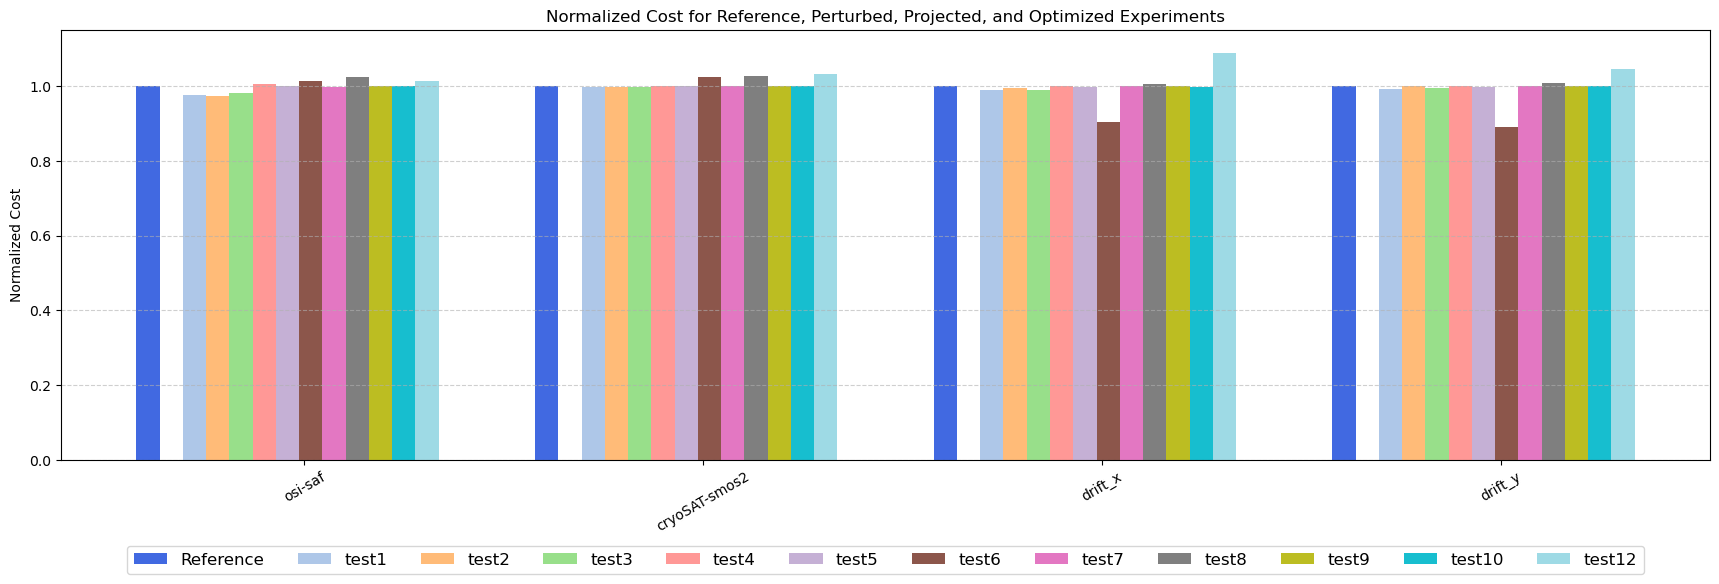

In [21]:
# ---- Plotting ----
group_width = 0.7           # total width of group
bar_width = group_width / (n_exp + 1)   # space for bars

x = np.arange(n_obs)

plt.figure(figsize=(18, 6))

# Reference
reference = np.ones(n_obs)
plt.bar(x - bar_width*(n_exp/2 + 2), reference, 
        width=bar_width, label="Reference", color="royalblue")

# Perturbed experiments 1–20
colors = plt.cm.tab20(np.linspace(0, 1, n_exp+1))
for i in range(n_exp):
    plt.bar(x - bar_width*(n_exp/2 - i), 
            cost[i,:], 
            width=bar_width, 
            #label=str(i+1) if i < 1 else "" ,   # show only 1 label
            label=par_labs[i+1],
            color=colors[i+1])

# Projected
#plt.bar(x + bar_width*(n_exp/2 + 1), projected,
#        width=bar_width, label="Projected", color="orange")

# Optimized
#plt.bar(x + bar_width*(n_exp/2 + 2), optimized,
#        width=bar_width, label="Optimized", color="lightblue")

# ---- Formatting ----
plt.xticks(x-0.045, obs_labs, rotation=30)
plt.ylabel("Normalized Cost")
plt.ylim(0, 1.15)
plt.title("Normalized Cost for Reference, Perturbed, Projected, and Optimized Experiments")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.legend(ncol=n_exp+1, loc='upper center', bbox_to_anchor=(0.5, -0.18), fontsize=12)
plt.tight_layout()
plt.show()

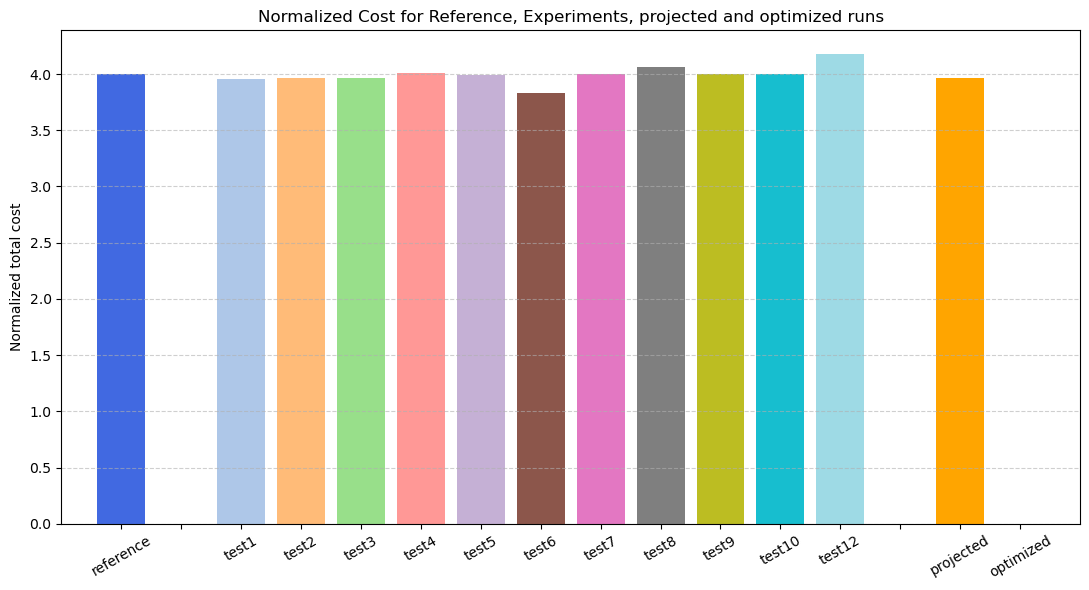

In [22]:

# ---- Plotting ----
#group_width = 0.7           # total width of group
#bar_width = group_width / (n_exp + 1)   # space for bars

plt.figure(figsize=(11, 6))

# Reference
reference = np.ones(n_obs)*4
plt.bar(-2, reference, 
        label="Reference", color="royalblue")

# Perturbed experiments 1–20
#colors = plt.cm.tab20(np.linspace(0, 1, n_exp+1))
for i in range(n_exp):
    plt.bar(i, 
            total_cost[i], 
            #label=str(i+1) if i < 1 else "" ,   # show only 1 label
            label=par_labs[i+1],
            color=colors[i+1])

# Projected
plt.bar(n_exp + 1, optimized_params[1,n_exp+1],
        label="Projected", color="orange")

# Optimized
#plt.bar(x + bar_width*(n_exp/2 + 2), optimized,
#        width=bar_width, label="Optimized", color="lightblue")

# ---- Formatting ----
exps_extended = ['reference', ' '] + par_labs[1:] + [' ', 'projected', 'optimized']
plt.xticks(np.arange(-2,n_exp+3), exps_extended, rotation=30)
plt.ylabel("Normalized total cost")
plt.ylim(0,)
plt.xlim(-3, n_exp+3)
plt.title("Normalized Cost for Reference, Experiments, projected and optimized runs")
plt.grid(axis='y', linestyle='--', alpha=0.6)

#plt.legend(ncol=n_exp+1, loc='upper center', bbox_to_anchor=(0.5, -0.18), fontsize=12)
plt.tight_layout()
plt.show()


STOP HERE

In [23]:
# next interaction? or OFF-diagonal elements?

Qd = 0
P = np.linalg.inv(Qd+GRG) # covariance matrix (equation 9 in paper)
eta = P @ np.transpose(G[ind,:]) @ ( Ri[ind,0] * Yd[ind,0] )        # multiplication factors with Q=0

eta_new = par_ref[1:] + (par_pert[1:] - par_ref[1:])*np.array(eta)

In [24]:
# projected and reference error
pe=np.nansum(W/R*(Yd[:,1]-(G @ eta))**2)
re=np.nansum(W/R*(Yd[:,1])**2)

optimized_params[0,0:n_exp]=eta_new
optimized_params[0,n_exp]=re
optimized_params[0,n_exp+1]=pe
ETA[0,:]=eta

In [25]:
print('optimized parameters ', optimized_params[1,0:n_exp])
print('reference error ', optimized_params[1,n_exp])
print('projected error ', optimized_params[1,n_exp+1])

optimized parameters  [1.25870518e+00 1.48541044e+03 9.51090880e-01 4.99516506e-02
 2.73803448e+04 5.54639061e-03 3.02680006e-01 3.30577697e+02
 1.58489683e-03 9.17594652e+02 5.05759713e-02]
reference error  3.99999999999999
projected error  3.963114981817429


In [43]:
# I am using this now
# with n_exps=11 and n_obs=4 this cell takes approximately 25 minutes to complete

for j in range(0, n_obs):

    G0  = np.zeros([len(ref_obs_scaled[j]), n_exp])    # model - reference difference (initialization) -- plus one to include reference cost function
    Yd0 = np.zeros([len(ref_obs_scaled[j]), n_exp])    # model - data difference (initialization)
    R0  = np.zeros(len(ref_obs_scaled[j]))             # Variance (initialization)

    # parameter perturbation experiments

    for i_exp in range(0,n_exp):

        exp_name = par_labs[i_exp + 1]
        print(obs_labs[j], ' : ', exp_name)

        dir_pars = dir_exps + exp_name + "/ice/hist/"
        ds_pert = xr.open_mfdataset(dir_pars + exp_name + ".cice.h.[0-9][0-9][0-9][0-9]-[0-9][0-9]_v1.nc")
        ds_pert = ds_pert.sel(time=slice(start_date, end_date))
        ds_pert = ds_pert.rename({'nj': 'y', 'ni': 'x'})

        # -- take sea ice concentration and use ravel to have a unique array
        var_exp = ds_pert[ref_obs_var[j]].where(masked_ds, drop=True).values.ravel()

        # -- Applying scaling correction to reference outputs
        var_exp_scaled = var_exp * scaling_array[j]

        # -- compute DATA KERNEL (perturbed experiment minus reference)
        G0[:,i_exp] = var_exp_scaled - ref_obs_scaled[j]

        # -- compute observation minus reference
        Yd0[:,i_exp] = obs_scaled[j] - ref_obs_scaled[j]  

        # -- compute denominator of cost function
        R0[:] = np.nansum(area_weights*(obs_scaled[j] - ref_obs_scaled[j])**2)
        
        cost[i_exp,j]=np.nansum(area_weights*(Yd0[:,i_exp] - G0[:,i_exp])**2/R0)   

    Yd=np.concatenate((Yd,Yd0))
    R=np.concatenate((R,R0))
    G=np.concatenate((G,G0))
    W=np.concatenate((W,area_weights))


# --  cost function shape
# [ cost_ref_obs1,  cost_ref_obs2  ]  , first row: [ 1, 1]
# [ cost_exp1_obs1, cost_exp1_obs2 ]
# [ cost_exp2_obs1, cost_exp2_obs2 ]

osi-saf  :  test1
osi-saf  :  test2
osi-saf  :  test3
osi-saf  :  test4
osi-saf  :  test5
osi-saf  :  test6
osi-saf  :  test7
osi-saf  :  test9
osi-saf  :  test10
osi-saf  :  test12
osi-saf  :  test13
cryoSAT-smos2  :  test1
cryoSAT-smos2  :  test2
cryoSAT-smos2  :  test3
cryoSAT-smos2  :  test4
cryoSAT-smos2  :  test5
cryoSAT-smos2  :  test6
cryoSAT-smos2  :  test7
cryoSAT-smos2  :  test9
cryoSAT-smos2  :  test10
cryoSAT-smos2  :  test12
cryoSAT-smos2  :  test13
drift_x  :  test1
drift_x  :  test2
drift_x  :  test3
drift_x  :  test4
drift_x  :  test5
drift_x  :  test6
drift_x  :  test7
drift_x  :  test9
drift_x  :  test10
drift_x  :  test12
drift_x  :  test13
drift_y  :  test1
drift_y  :  test2
drift_y  :  test3
drift_y  :  test4
drift_y  :  test5
drift_y  :  test6
drift_y  :  test7
drift_y  :  test9
drift_y  :  test10
drift_y  :  test12
drift_y  :  test13


In [ ]:
# 
# version without scaling factors 1/N: run either this or the previous cell.
#
for j in range(0, n_obs):

    G0  = np.zeros([len(ref_obs_scaled[j]), n_exp])    # model - reference difference (initialization) -- plus one to include reference cost function
    Yd0 = np.zeros([len(ref_obs_scaled[j]), n_exp])    # model - data difference (initialization)
    R0  = np.zeros(len(ref_obs_scaled[j]))             # Variance (initialization)

    # parameter perturbation experiments

    for i_exp in range(0,n_exp):

        exp_name = par_labs[i_exp + 1]
        print(obs_labs[j], ' : ', exp_name)

        dir_pars = dir_exps + exp_name + "/ice/hist/"
        ds_pert = xr.open_mfdataset(dir_pars + exp_name + ".cice.h.[0-9][0-9][0-9][0-9]-[0-9][0-9]_v1.nc")
        ds_pert = ds_pert.sel(time=slice(start_date, end_date))
        ds_pert = ds_pert.rename({'nj': 'y', 'ni': 'x'})        

        # -- take sea ice concentration and use ravel to have a unique array
        var_exp = ds_pert[ref_obs_var[j]].where(masked_ds, drop=True).values.ravel()

        # -- Applying scaling correction to reference outputs
        #var_exp_scaled = var_exp * scaling_array[j]            ###### here is the change
        var_exp_scaled = var_exp                                    

        # -- compute DATA KERNEL (perturbed experiment minus reference)
        G0[:,i_exp] = var_exp_scaled - ref_obs_nonscaled[j]

        # -- compute observation minus reference
        Yd0[:,i_exp] = obs_nonscaled[j] - ref_obs_nonscaled[j]  

        # -- compute denominator of cost function
        R0[:] = np.nansum(area_weights*(obs_nonscaled[j] - ref_obs_nonscaled[j])**2)

                                                                ###### here is the change
        
        cost[i_exp,j]=np.nansum(area_weights*(Yd0[:,i_exp] - G0[:,i_exp])**2/R0)   

    Yd=np.concatenate((Yd,Yd0))
    R=np.concatenate((R,R0))
    G=np.concatenate((G,G0))
    W=np.concatenate((W,area_weights))


# --  cost function shape
# [ cost_ref_obs1,  cost_ref_obs2  ]  , first row: [ 1, 1]
# [ cost_exp1_obs1, cost_exp1_obs2 ]
# [ cost_exp2_obs1, cost_exp2_obs2 ]

osi-saf  :  test1
osi-saf  :  test2
osi-saf  :  test3
osi-saf  :  test4
cryoSAT-smos2  :  test1
cryoSAT-smos2  :  test2
cryoSAT-smos2  :  test3
cryoSAT-smos2  :  test4
drift_x  :  test1
drift_x  :  test2
drift_x  :  test3
drift_x  :  test4
drift_y  :  test1
drift_y  :  test2
drift_y  :  test3
drift_y  :  test4
